In [1]:
# plotting
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# calculation
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

In this notebook: Creating ground-to-300 hPa OMI/MLS Trop. Ozone climatology from NASA Goddard (https://acd-ext.gsfc.nasa.gov/Data_services/cloud_slice/) and saving as monthly files/plotting purposes

In [2]:
dataset = xr.open_dataset("/glade/u/home/mvoncyga/SOARS_2025/input/omi_mls/tco100_omimls_oct2004_to_dec2024_1by1.nc")

So now it is time for some data cleaning, there should not be any negative values in the data

In [3]:
ozone = dataset["TropoO3"]
cleaned_ozone_dataset = ozone.where(ozone >= 0)
dataset["TropoO3"] = cleaned_ozone_dataset

In [4]:
ozone = cleaned_ozone_dataset 

# adding month from attributes to coordinate
month = ozone.attrs['Month'].split(',')
first_month = month[0]                              # October 2004
last_month = month[-1].replace(' ', '')             # December 2024

start_date = datetime.strptime(first_month, "%b%Y")
end_date = datetime.strptime(last_month, "%b%Y")

time_coords = pd.date_range(start=start_date, end=end_date, freq='MS')

In [5]:
# renaming and assigning/removing dimensions
ozone = ozone.assign_coords(time=('months', time_coords))
ozone = ozone.rename({"time": "yearmonth",'y_elements': 'latitude', 'x_elements': 'longitude'})
ozone = ozone.swap_dims({'months': 'yearmonth'})

Subsetting necessary months. This is January 2005 - December 2024

In [6]:
#### Choose desired date range ####
ozone_subsetted = ozone.sel(yearmonth=slice("2005-01-01", "2024-12-01")) 

In [7]:
ozone_mean_subsetted = ozone_subsetted.assign_attrs(_FillValue="-999",name="Tropospheric Ozone Mean, Ground to 100 hPa", latitude="-75.5, -59.5, -58.5, ..., 59.5, 75.5")
ozone_stdev_subsetted = ozone_subsetted.assign_attrs(_FillValue="-999",name="Tropospheric Ozone STDEV, Ground to 100 hPa", latitude="-75.5, -59.5, -58.5, ..., 59.5, 75.5")

del ozone_mean_subsetted.attrs['Month']
del ozone_stdev_subsetted.attrs['Month']

In [8]:
# adding lat/lon from attributes to coordinates
lat_coords = ozone_subsetted.attrs['latitude'].split(',')
first_lat = float(lat_coords[0])
last_lat = float(lat_coords[-1])

lon_coords = ozone_subsetted.attrs['longitude'].split(',')
first_lon = float(lon_coords[0])
last_lon = float(lon_coords[-1])

lon_coords = np.arange(first_lon, 180.5, 1)
lat_coords = np.arange(first_lat,90.5, 1)

ozone_mean_subsetted = ozone_mean_subsetted.assign_coords(
    longitude=('longitude', lon_coords),
    latitude=('latitude', lat_coords)
)

ozone_stdev_subsetted = ozone_stdev_subsetted.assign_coords(
    longitude=('longitude', lon_coords),
    latitude=('latitude', lat_coords)
)

In [9]:
# grouping by calendar month
monthly_mean = ozone_mean_subsetted.groupby('yearmonth.month').mean('yearmonth')
monthly_stdev = ozone_stdev_subsetted.groupby('yearmonth.month').std('yearmonth') # group it with means

# grouping by season
seasonal_mean = ozone_mean_subsetted.groupby('yearmonth.season').mean('yearmonth')
seasonal_stdev = ozone_stdev_subsetted.groupby('yearmonth.season').std('yearmonth')

Now truncate to 75°S-75°N, add fill value, and save as NETCDF4 files

In [10]:
mean_netcdf_dataset = monthly_mean.sel(latitude=slice(-75.5,75.5))
stdev_netcdf_dataset = monthly_stdev.sel(latitude=slice(-75.5,75.5))

In [11]:
mean_netcdf_dataset.fillna(-999)

<xarray.DataArray 'TropoO3' (month: 12, latitude: 152, longitude: 360)> Size: 3MB
array([[[  67.68822 ,   67.7697  ,   67.88566 , ...,   68.38742 ,
           68.32687 ,   68.2897  ],
        [  67.6784  ,   67.67044 ,   67.765045, ...,   68.69369 ,
           68.36792 ,   68.25617 ],
        [  67.3045  ,   67.26289 ,   67.28155 , ...,   68.15848 ,
           67.88284 ,   67.83311 ],
        ...,
        [-999.      , -999.      , -999.      , ..., -999.      ,
         -999.      , -999.      ],
        [-999.      , -999.      , -999.      , ..., -999.      ,
         -999.      , -999.      ],
        [-999.      , -999.      , -999.      , ..., -999.      ,
         -999.      , -999.      ]],

       [[  71.9485  ,   72.06791 ,   72.18311 , ...,   72.40155 ,
           72.297295,   72.25132 ],
        [  71.69172 ,   71.72636 ,   71.87551 , ...,   72.57808 ,
           71.96946 ,   71.906525],
        [  71.16115 ,   71.15555 ,   71.19042 , ...,   71.915405,
           71.46195 ,   71.370865],
...
        [-999.      , -999.      , -999.      , ..., -999.      ,
         -999.      , -999.      ],
        [-999.      , -999.      , -999.      , ..., -999.      ,
         -999.      , -999.      ],
        [-999.      , -999.      , -999.      , ..., -999.      ,
         -999.      , -999.      ]],

       [[  64.99811 ,   65.141815,   65.38633 , ...,   63.992603,
           64.00437 ,   63.998165],
        [  65.12941 ,   65.196266,   65.16689 , ...,   65.38612 ,
           64.90483 ,   64.61473 ],
        [  65.70442 ,   66.0491  ,   66.23002 , ...,   65.23577 ,
           64.68194 ,   64.68024 ],
        ...,
        [-999.      , -999.      , -999.      , ..., -999.      ,
         -999.      , -999.      ],
        [-999.      , -999.      , -999.      , ..., -999.      ,
         -999.      , -999.      ],
        [-999.      , -999.      , -999.      , ..., -999.      ,
         -999.      , -999.      ]]], dtype=float32)
Coordinates:
  * longitude  (longitude) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
  * latitude   (latitude) float64 1kB -75.5 -74.5 -73.5 -72.5 ... 73.5 74.5 75.5
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Attributes:
    units:       Dobson Units
    name:        Tropospheric Ozone Mean, Ground to 100 hPa
    latitude:    -75.5, -59.5, -58.5, ..., 59.5, 75.5
    longitude:   -179.5, -178.5, ..., 179.5
    _FillValue:  -999

In [12]:
#mean_netcdf_dataset.to_netcdf(path="/glade/u/home/mvoncyga/SOARS_2025/data/OMI_MLS_climatology_files/OMI_MLS_100hpa_monthly_mean_2005_2024.nc",format="NETCDF4")

In [13]:
stdev_netcdf_dataset.fillna(-999)

<xarray.DataArray 'TropoO3' (month: 12, latitude: 152, longitude: 360)> Size: 3MB
array([[[   6.2048907,    6.181857 ,    6.1696177, ...,    6.1308455,
            6.105828 ,    6.101435 ],
        [   6.3359027,    6.402995 ,    6.45779  , ...,    6.1047153,
            6.061098 ,    6.0351534],
        [   5.944087 ,    5.9827175,    6.0223284, ...,    5.7591786,
            5.7808123,    5.810983 ],
        ...,
        [-999.       , -999.       , -999.       , ..., -999.       ,
         -999.       , -999.       ],
        [-999.       , -999.       , -999.       , ..., -999.       ,
         -999.       , -999.       ],
        [-999.       , -999.       , -999.       , ..., -999.       ,
         -999.       , -999.       ]],

       [[   4.039553 ,    4.0369854,    3.9165394, ...,    3.7756536,
            3.752294 ,    3.7440507],
        [   4.2694736,    4.2382646,    4.1963096, ...,    4.0222893,
            4.0159793,    4.0443845],
        [   4.3578553,    4.358829 ,    4.3405128, ...,    4.056794 ,
            4.040615 ,    4.027877 ],
...
        [-999.       , -999.       , -999.       , ..., -999.       ,
         -999.       , -999.       ],
        [-999.       , -999.       , -999.       , ..., -999.       ,
         -999.       , -999.       ],
        [-999.       , -999.       , -999.       , ..., -999.       ,
         -999.       , -999.       ]],

       [[   7.677855 ,    7.6396375,    7.595312 , ...,    9.146762 ,
            9.067926 ,    9.044633 ],
        [   8.132752 ,    8.084743 ,    8.205839 , ...,    9.145564 ,
            9.213081 ,    9.341727 ],
        [   7.6322455,    7.5379004,    7.5141225, ...,    8.699458 ,
            9.044306 ,    9.041484 ],
        ...,
        [-999.       , -999.       , -999.       , ..., -999.       ,
         -999.       , -999.       ],
        [-999.       , -999.       , -999.       , ..., -999.       ,
         -999.       , -999.       ],
        [-999.       , -999.       , -999.       , ..., -999.       ,
         -999.       , -999.       ]]], dtype=float32)
Coordinates:
  * longitude  (longitude) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
  * latitude   (latitude) float64 1kB -75.5 -74.5 -73.5 -72.5 ... 73.5 74.5 75.5
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Attributes:
    units:       Dobson Units
    name:        Tropospheric Ozone STDEV, Ground to 100 hPa
    latitude:    -75.5, -59.5, -58.5, ..., 59.5, 75.5
    longitude:   -179.5, -178.5, ..., 179.5
    _FillValue:  -999

In [14]:
#stdev_netcdf_dataset.to_netcdf(path="/glade/u/home/mvoncyga/SOARS_2025/data/OMI_MLS_climatology_files/OMI_MLS_300hpa_monthly_stdev_2005_2024.nc",format="NETCDF4")

Plotting

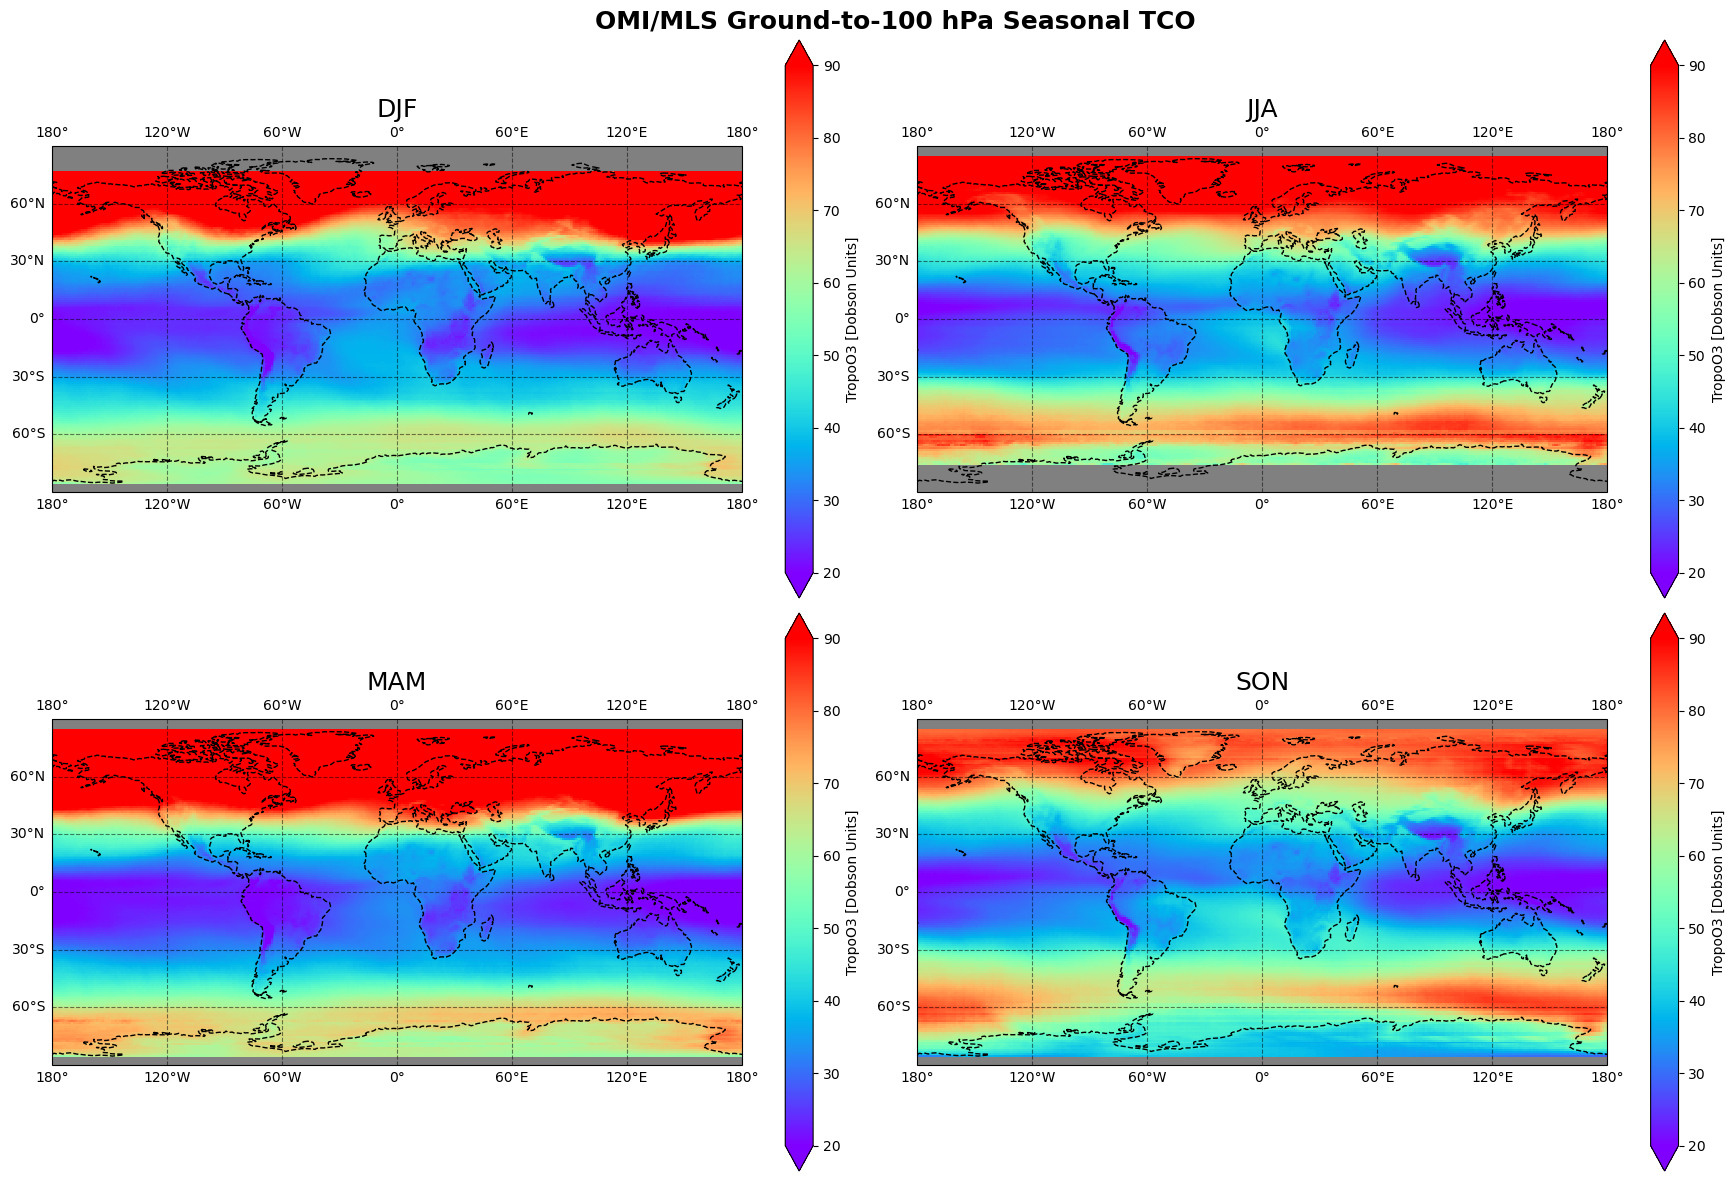

In [28]:
seasonal_list = ['DJF', 'JJA', 'MAM', 'SON']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12), subplot_kw=dict(projection=ccrs.PlateCarree()))

for i, ax in enumerate(axes.ravel()):
    #ax.spines[axis].set_linewidth(100.5)
    seasonal_mean[i].plot(ax=ax,transform=ccrs.PlateCarree(central_longitude=0), vmin=20, vmax=90, extend='both', cmap='rainbow')
    ax.set_global()
    ax.set_facecolor('gray')
    gl = ax.gridlines(draw_labels=True, color='black', alpha=0.5, linestyle='--')
    gl.right_labels = False
    

    ax.add_feature(cfeature.COASTLINE, linestyle='--')
    ax.set_title(f'{seasonal_list[i]}', fontsize=18)
    fig.suptitle('OMI/MLS Ground-to-100 hPa Seasonal TCO', fontsize=18, fontweight='bold')
    plt.tight_layout()


#plt.savefig("/glade/u/home/mvoncyga/SOARS_2025/figures/climatology_omi_mls/100hpa_seasonal")
plt.show()

In [1]:
month_list = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 14), subplot_kw=dict(projection=ccrs.PlateCarree()))

for i, ax in enumerate(axes.ravel()):
    monthly_mean[i].plot(ax=ax, transform=ccrs.PlateCarree(), extend='both', vmin=10, vmax=90, cmap='viridis')
    ax.set_facecolor('gray')
    ax.set_global()
    gl = ax.gridlines(draw_labels=True, color='black', alpha=0.5, linestyle='--')
    gl.right_labels = False

    ax.add_feature(cfeature.COASTLINE, linestyle='--')
    ax.set_title(f'{month_list[i]}')
    plt.suptitle("OMI/MLS Ground-to-100 hPa TCO", 
                 fontsize=18, fontweight='bold')
    plt.tight_layout()

#plt.savefig("/glade/u/home/mvoncyga/SOARS_2025/figures/climatology_omi_mls/100hpa_monthly")
plt.show()

NameError: name 'plt' is not defined